# Notebook 03 — Principal Component Analysis (from scratch)

This notebook decomposes the 8-stock covariance matrix $\Sigma$ into independent risk factors using **Principal Component Analysis**, implemented from scratch with NumPy.

**Why implement PCA from scratch?** While `sklearn.decomposition.PCA` exists, building it manually shows the underlying linear algebra explicitly: eigendecomposition of $\Sigma$, projection of data onto the principal component basis, and reconstruction from a reduced number of components. We verify our implementation against sklearn at the end of the notebook.

**Theoretical foundation:**

$$\Sigma = V \Lambda V^T$$

where $V$ is the orthogonal matrix of eigenvectors (each column is a principal component) and $\Lambda$ is the diagonal matrix of eigenvalues (each is the variance along the corresponding PC).

**Financial interpretation:** PC1 typically captures a "market factor" (broad co-movement across all stocks), PC2 often distinguishes sectors (e.g. banks vs. real estate), and higher PCs capture idiosyncratic risk.

**Inputs (from Notebook 02):**
- `data/returns.csv` — daily simple returns, 870 × 8
- `data/cov_matrix.csv` — covariance matrix $\Sigma \in \mathbb{R}^{8 \times 8}$

## 1. Setup and load data

We reload the returns matrix and the covariance matrix computed in Notebook 02.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

np.random.seed(42)

# Annualization factor for HOSE
TRADING_DAYS = 250

# Load returns (datetime index)
returns = pd.read_csv('../data/returns.csv')
returns['time'] = pd.to_datetime(returns['time'])
returns = returns.set_index('time')

# Load covariance matrix (ticker index)
cov = pd.read_csv('../data/cov_matrix.csv', index_col=0)

print(f'Returns shape:    {returns.shape}')
print(f'Covariance shape: {cov.shape}')
print(f'Tickers: {cov.columns.tolist()}')

Returns shape:    (870, 8)
Covariance shape: (8, 8)
Tickers: ['VNM', 'VIC', 'VHM', 'FPT', 'HPG', 'MWG', 'VCB', 'MBB']


In [2]:
# Convert to NumPy array for cleaner linear algebra operations
Sigma = cov.values
tickers = cov.columns.tolist()

print(f'Shape of Σ: {Sigma.shape}')
print(f'Dtype: {Sigma.dtype}\n')

# --- Check 1: Symmetry ---
symmetry_error = np.max(np.abs(Sigma - Sigma.T))
is_symmetric = np.allclose(Sigma, Sigma.T)

print('Check 1 — Symmetry')
print(f'  Max |Σ - Σᵀ|: {symmetry_error:.2e}')
print(f'  Is symmetric (within tolerance): {is_symmetric}\n')

# --- Check 2: Positive Semi-Definite ---
# A matrix is PSD iff all eigenvalues are >= 0
eigenvalues_check = np.linalg.eigvalsh(Sigma)
min_eigenvalue = eigenvalues_check.min()
is_psd = min_eigenvalue >= -1e-10  # tolerance for floating-point errors

print('Check 2 — Positive Semi-Definite')
print(f'  Min eigenvalue: {min_eigenvalue:.2e}')
print(f'  Is PSD (within tolerance): {is_psd}')
print(f'  All eigenvalues > 0 (strictly PD): {(eigenvalues_check > 0).all()}')

Shape of Σ: (8, 8)
Dtype: float64

Check 1 — Symmetry
  Max |Σ - Σᵀ|: 0.00e+00
  Is symmetric (within tolerance): True

Check 2 — Positive Semi-Definite
  Min eigenvalue: 1.18e-04
  Is PSD (within tolerance): True
  All eigenvalues > 0 (strictly PD): True


## 3. Eigendecomposition

We use `np.linalg.eigh` rather than `np.linalg.eig` because $\Sigma$ is symmetric. `eigh`:

- guarantees real-valued eigenvalues (no spurious imaginary parts from floating-point noise),
- guarantees an orthogonal eigenvector matrix ($V^T V = I$), and
- uses an algorithm optimized for symmetric matrices (LAPACK's `syevd`), which is both faster and more numerically stable.

**Convention note:** `eigh` returns eigenvalues in **ascending** order, but PCA convention is **descending** order (largest variance first). We sort manually using `np.argsort(...)[::-1]`, and apply the same reordering to the eigenvector columns to preserve the eigenvalue–eigenvector pairing.

After this step:
- `eigenvalues[i]` = $\lambda_{i+1}$ = variance along the $(i+1)$-th principal component
- `eigenvectors[:, i]` = $v_{i+1}$ = direction of the $(i+1)$-th principal component (a unit vector in $\mathbb{R}^8$)

In [3]:
# Eigendecomposition of Σ
# Note: eigh assumes Σ is symmetric (which we verified in Section 2)
eigenvalues_raw, eigenvectors_raw = np.linalg.eigh(Sigma)

print(f'Eigenvalues shape:  {eigenvalues_raw.shape}')
print(f'Eigenvectors shape: {eigenvectors_raw.shape}')
print(f'\nEigenvalues (raw, ascending order from eigh):')
print(eigenvalues_raw)

# eigh returns eigenvalues in ASCENDING order
# For PCA we want DESCENDING (largest variance first)
sort_idx = np.argsort(eigenvalues_raw)[::-1]
eigenvalues = eigenvalues_raw[sort_idx]
eigenvectors = eigenvectors_raw[:, sort_idx]

print(f'\nEigenvalues (sorted descending):')
for i, lam in enumerate(eigenvalues):
    print(f'  λ_{i+1} = {lam:.6f}')

Eigenvalues shape:  (8,)
Eigenvectors shape: (8, 8)

Eigenvalues (raw, ascending order from eigh):
[0.000118   0.00014491 0.00014787 0.00015886 0.00021695 0.00025467
 0.00044944 0.00137637]

Eigenvalues (sorted descending):
  λ_1 = 0.001376
  λ_2 = 0.000449
  λ_3 = 0.000255
  λ_4 = 0.000217
  λ_5 = 0.000159
  λ_6 = 0.000148
  λ_7 = 0.000145
  λ_8 = 0.000118


### 3.1 Verify the decomposition

We verify three properties to confirm the eigendecomposition is correct:

1. **Orthogonality of $V$**: $V^T V = I$ — eigenvectors form an orthonormal basis.
2. **Reconstruction**: $V \Lambda V^T = \Sigma$ — the decomposition recovers the original matrix.
3. **Trace preservation**: $\text{trace}(\Sigma) = \sum_i \lambda_i$ — total variance is conserved.

All three errors should be at floating-point precision (~$10^{-16}$).

In [4]:
V = eigenvectors
Lambda = np.diag(eigenvalues)

# Verify 1: V is orthogonal (V^T V = I)
VtV = V.T @ V
identity = np.eye(8)
orthogonality_error = np.max(np.abs(VtV - identity))
print(f'Verification 1 — V is orthogonal')
print(f'  Max |V^T V - I|: {orthogonality_error:.2e}')

# Verify 2: Reconstruction Σ = V Λ V^T
Sigma_reconstructed = V @ Lambda @ V.T
reconstruction_error = np.max(np.abs(Sigma - Sigma_reconstructed))
print(f'\nVerification 2 — Reconstruction Σ = V Λ Vᵀ')
print(f'  Max |Σ - V Λ Vᵀ|: {reconstruction_error:.2e}')

# Verify 3: Trace preserved (sum of eigenvalues = sum of diagonal of Σ)
trace_Sigma = np.trace(Sigma)
sum_eigenvalues = eigenvalues.sum()
print(f'\nVerification 3 — Trace preservation')
print(f'  trace(Σ) = {trace_Sigma:.6f}')
print(f'  Σ λᵢ    = {sum_eigenvalues:.6f}')
print(f'  Difference: {abs(trace_Sigma - sum_eigenvalues):.2e}')

Verification 1 — V is orthogonal
  Max |V^T V - I|: 1.78e-15

Verification 2 — Reconstruction Σ = V Λ Vᵀ
  Max |Σ - V Λ Vᵀ|: 5.42e-19

Verification 3 — Trace preservation
  trace(Σ) = 0.002867
  Σ λᵢ    = 0.002867
  Difference: 1.30e-18


## 4. Explained variance ratio

Each eigenvalue $\lambda_i$ tells us the variance along the corresponding principal component. To make this comparable, we normalize by the total variance:

$$\text{ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{8} \lambda_j}, \qquad \text{cumulative}_k = \sum_{i=1}^{k} \text{ratio}_i$$

Recall from Section 3 that $\sum_j \lambda_j = \text{trace}(\Sigma)$, so the denominator is the total variance of the original 8 stocks.

The ratios answer the central question of PCA: **how much of the data's variability is captured by each component, and how many components do we need to retain most of the information?**

In [5]:
# Total variance = sum of eigenvalues = trace(Σ)
total_variance = eigenvalues.sum()

# Explained variance ratio (per component)
explained_variance_ratio = eigenvalues / total_variance

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Build a summary DataFrame
variance_df = pd.DataFrame({
    'eigenvalue':      eigenvalues,
    'variance_ratio':  explained_variance_ratio,
    'cumulative':      cumulative_variance,
}, index=[f'PC{i+1}' for i in range(len(eigenvalues))])

variance_df.round(4)

,eigenvalue,variance_ratio,cumulative
PC1,0.0014,0.4801,0.4801
PC2,0.0004,0.1568,0.6368
PC3,0.0003,0.0888,0.7256
PC4,0.0002,0.0757,0.8013
PC5,0.0002,0.0554,0.8567
PC6,0.0001,0.0516,0.9083
PC7,0.0001,0.0505,0.9588
PC8,0.0001,0.0412,1.0000


**Reading the table:**

- **PC1 alone** captures ~48% of total variance — a single direction in 8-dimensional space explains nearly half of the joint dynamics of these stocks. This is the signature of a **dominant market factor** common to Vietnamese blue-chips.
- **PC1 + PC2** together explain ~64%.
- The first 5 PCs cumulatively explain ~86%; we could drop PC6–PC8 and lose only ~14% of the information.
- The last few eigenvalues are similar in magnitude (~0.0001–0.00015) — this is typical "noise floor" behavior in financial data.

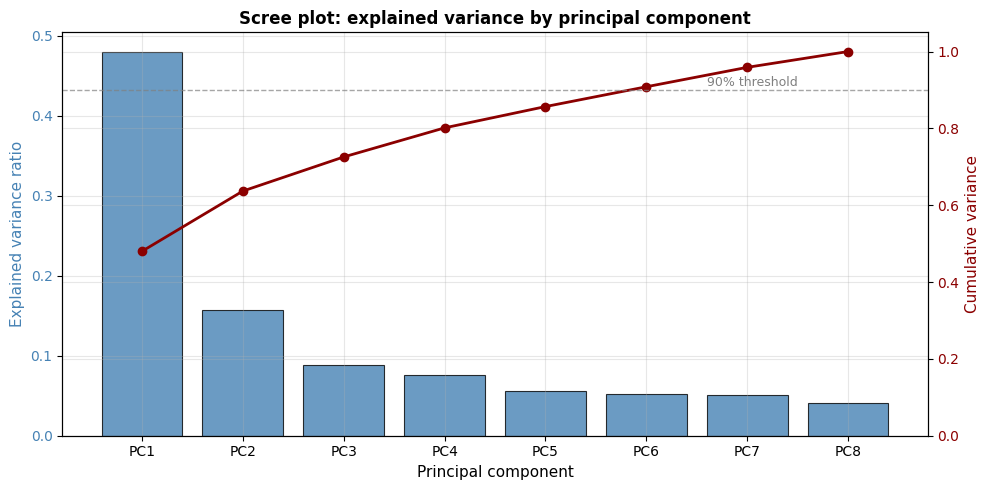

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart: per-PC variance ratio (left y-axis)
x = np.arange(1, len(eigenvalues) + 1)
ax1.bar(x, explained_variance_ratio, color='steelblue', alpha=0.8,
        edgecolor='black', linewidth=0.8, label='Per-PC ratio')
ax1.set_xlabel('Principal component', fontsize=11)
ax1.set_ylabel('Explained variance ratio', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels([f'PC{i}' for i in x])

# Line: cumulative variance (right y-axis)
ax2 = ax1.twinx()
ax2.plot(x, cumulative_variance, color='darkred', marker='o',
         linewidth=2, label='Cumulative')
ax2.set_ylabel('Cumulative variance', fontsize=11, color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.set_ylim(0, 1.05)
ax2.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.text(7.5, 0.91, '90% threshold', fontsize=9, color='gray', ha='right')

plt.title('Scree plot: explained variance by principal component',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**

- A clear "elbow" appears between PC1 and PC2: PC1 dominates while PC2 onwards drop sharply.
- The cumulative line crosses **90% at PC6**, meaning we need 6 components to retain 90% of the variance — relatively many because Vietnamese single-country stocks share substantial systematic risk but also have meaningful idiosyncratic variation.
- Components PC5–PC8 have similar small magnitudes, suggesting they capture stock-specific noise rather than structured factors.

## 5. Interpret PCs through loadings

Each eigenvector $v_i \in \mathbb{R}^8$ is a unit vector in stock space. Its components are called **loadings** — the weight of each stock in that principal component. The loadings tell us *what each PC represents* in financial terms.

**Reading guide:**

| Pattern in loadings              | Interpretation                                |
|----------------------------------|-----------------------------------------------|
| All same sign, similar magnitude | **Market factor** — stocks co-move broadly    |
| Split into two sign groups       | **Contrast factor** — distinguishes sectors   |
| One or two stocks dominate       | **Idiosyncratic** — stock-specific variation  |

**A note on sign ambiguity:** if $v$ is an eigenvector, so is $-v$ with the same eigenvalue. The choice of sign is therefore arbitrary in any numerical eigendecomposition. We interpret loadings by their **pattern** (signs relative to each other and magnitudes), not by absolute sign.

In [7]:
# Build loadings DataFrame
# Each column = one PC, each row = one stock
loadings = pd.DataFrame(
    eigenvectors,
    index=tickers,
    columns=[f'PC{i+1}' for i in range(len(eigenvalues))]
)

print('Loadings matrix (rows = stocks, columns = PCs):')
loadings.round(3)

Loadings matrix (rows = stocks, columns = PCs):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
VNM,-0.193,0.017,0.021,-0.431,-0.374,0.076,-0.515,0.605
VIC,-0.296,-0.686,0.157,0.143,-0.153,0.599,0.043,-0.113
VHM,-0.360,-0.549,-0.022,-0.082,0.242,-0.701,0.027,0.104
FPT,-0.317,0.174,0.228,-0.270,-0.652,-0.214,0.373,-0.365
HPG,-0.457,0.173,-0.646,0.500,-0.224,-0.034,-0.194,-0.071
MWG,-0.477,0.346,0.648,0.316,0.278,0.005,-0.236,0.011
VCB,-0.225,0.066,-0.204,-0.549,0.345,0.155,-0.362,-0.572
MBB,-0.397,0.208,-0.209,-0.251,0.326,0.269,0.607,0.380


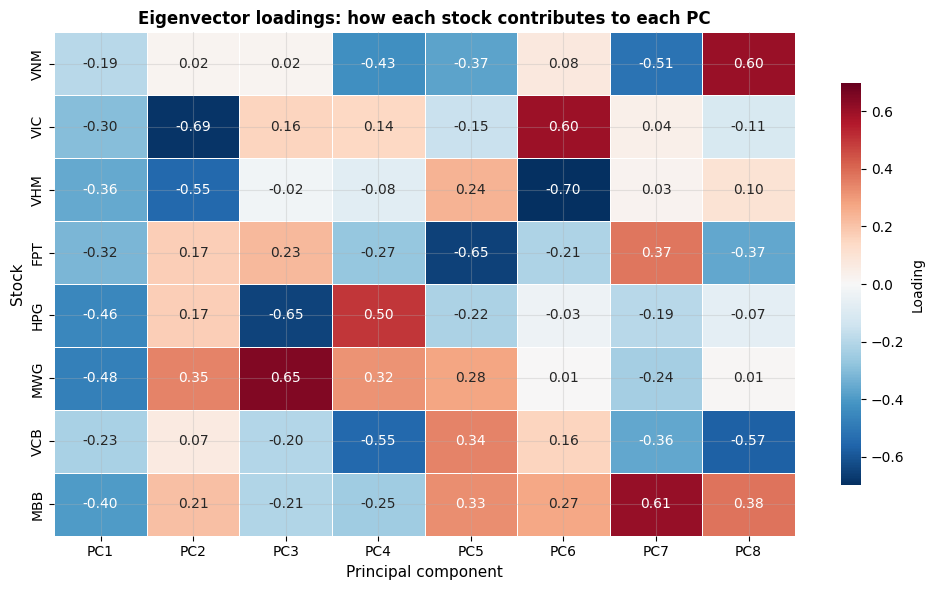

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.7, vmax=0.7,
            cbar_kws={'label': 'Loading', 'shrink': 0.8},
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Eigenvector loadings: how each stock contributes to each PC',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Principal component', fontsize=11)
ax.set_ylabel('Stock', fontsize=11)
plt.tight_layout()
plt.show()

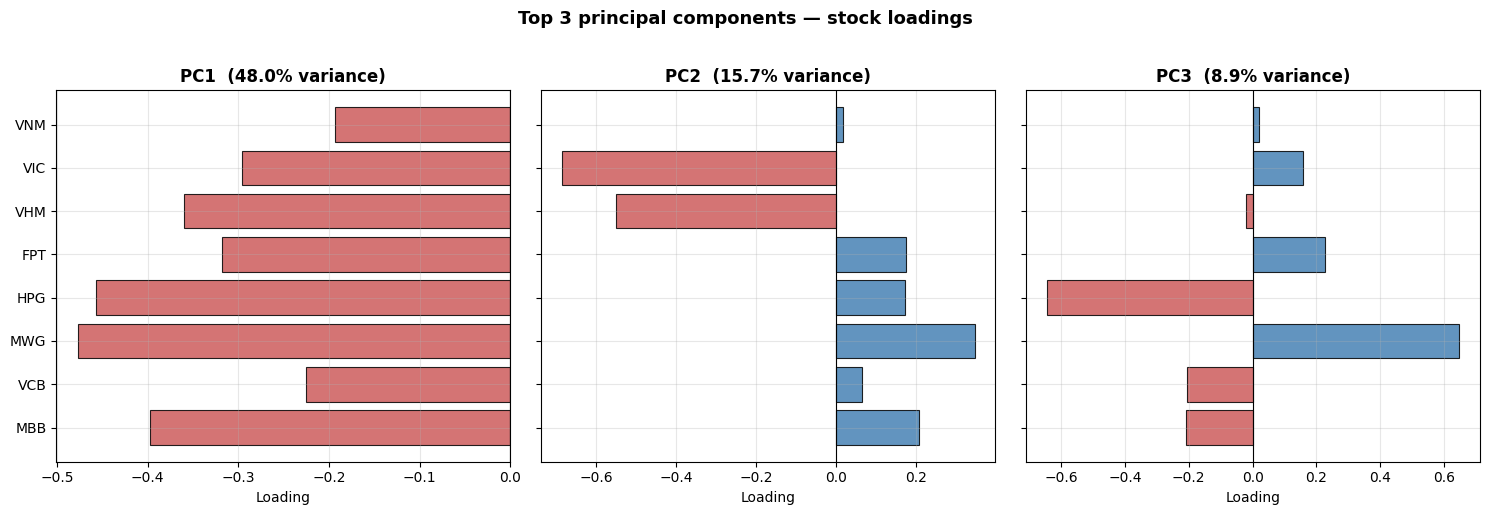

In [9]:
n_top = 3  # Focus on top 3 PCs which together explain ~73% of variance
fig, axes = plt.subplots(1, n_top, figsize=(15, 5), sharey=True)

for i in range(n_top):
    pc_name = f'PC{i+1}'
    pc_loadings = loadings[pc_name]
    colors = ['steelblue' if v > 0 else 'indianred' for v in pc_loadings]
    
    axes[i].barh(pc_loadings.index, pc_loadings.values,
                 color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{pc_name}  ({explained_variance_ratio[i]*100:.1f}% variance)',
                      fontweight='bold')
    axes[i].set_xlabel('Loading')
    axes[i].grid(axis='x', alpha=0.3)
    axes[i].invert_yaxis()  # Top stock at top

plt.suptitle('Top 3 principal components — stock loadings',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Financial interpretation:**

**PC1 — Market factor (~48% variance):**
All 8 stocks load in the same direction with similar magnitudes (0.19 to 0.48). This is the classic **market factor** signature: when "Vietnamese blue-chips go up", PC1 captures that broad co-movement. Note that magnitudes vary meaningfully:

- **High loadings (cyclical):** MWG (0.48, retail), HPG (0.46, steel), MBB (0.40, bank) — these stocks have **high market beta** and amplify systematic moves.
- **Low loadings (defensive):** VNM (0.19, dairy consumer staple), VCB (0.23, the largest VN bank) — these are **defensive stocks** less sensitive to market swings.

This is systematic risk that **cannot be diversified away** within a long-only Vietnamese equity portfolio.

**PC2 — Vingroup factor (~16% variance):**
PC2 sharply contrasts **VIC (–0.69)** and **VHM (–0.55)** against all other stocks (which load slightly positive). This isolates the **Vingroup ecosystem** as an independent risk dimension — consistent with our finding in Notebook 02 that VIC–VHM had the highest pairwise correlation (0.61). 

Practically: if an investor is concerned about Vingroup-specific risk (e.g., real estate sector slowdown), PC2 quantifies that exposure as a distinct factor that overweighting MWG (+0.35) and MBB (+0.21) can help hedge.

**PC3 — Steel vs Retail factor (~9% variance):**
PC3 is dominated by an almost symmetric opposition between **HPG (–0.65)** and **MWG (+0.65)**, with other stocks contributing little. These two represent opposite ends of the economic cycle:

- **HPG (steel)** depends on construction demand, global commodity prices, and real estate activity.
- **MWG (consumer electronics retail)** depends on domestic purchasing power and consumer confidence.

PC3 thus captures the **commodity cycle vs consumer cycle divergence** — periods when these two business drivers move out of sync.

**PCs 4–8** capture progressively smaller, more idiosyncratic variations (each <8% variance). These are the components that diversification *can* address — they represent stock-specific risk uncorrelated with broader systematic factors.

**Takeaway:** The 8-dimensional dynamics of HOSE blue-chips can be summarized by 3 interpretable factors explaining ~73% of variance: (1) broad market, (2) Vingroup ecosystem, and (3) commodity-vs-consumer cycle. This dimensional reduction provides a useful mental model for risk attribution.

## 6. Project data onto PC space

So far we have the principal component **directions** (eigenvectors $V$) and their **importance** (eigenvalues $\lambda_i$). To actually *use* PCA, we need to express our 870 days of returns in this new coordinate system:

$$Y = X V$$

where $X$ is the (centered) returns matrix and $Y$ contains the **PC scores** — coordinates of each day in the new basis. The interpretation:

- Each row of $Y$ = one day's returns expressed in PC coordinates.
- Each column of $Y$ = one PC's behavior over time (a time series).
- Columns of $Y$ are **uncorrelated** by construction (unlike columns of $X$).
- $\text{Var}(\text{column } i \text{ of } Y) = \lambda_i$.

**Centering:** standard PCA practice centers data ($X - \bar{X}$) before projection. For daily returns the means are tiny (~10⁻⁴), so the effect is small, but we still center for correctness.

In [10]:
# Project returns onto PC space: Y = X @ V
X = returns.values  # (870, 8) numpy array

# Center the data (subtract mean from each column)
# This is technically the "standard" PCA preprocessing,
# though for daily returns the means are tiny so the effect is small.
X_centered = X - X.mean(axis=0)

# Project: each row of Y is one day's returns expressed in PC coordinates
Y = X_centered @ eigenvectors

# Wrap in a DataFrame for convenience
pc_scores = pd.DataFrame(
    Y,
    index=returns.index,
    columns=[f'PC{i+1}' for i in range(Y.shape[1])]
)

print(f'PC scores shape: {pc_scores.shape}')
pc_scores.head().round(4)

PC scores shape: (870, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
time,,,,,,,,
2021-11-02,0.0018,-0.0077,-0.0050,-0.0066,0.0050,-0.0057,0.0047,-0.0103
2021-11-03,0.0003,0.0224,-0.0095,-0.0039,0.0100,0.0217,0.0173,-0.0030
2021-11-04,-0.0038,0.0061,-0.0012,0.0125,-0.0045,-0.0029,-0.0109,0.0001
2021-11-05,-0.0079,0.0111,0.0147,0.0082,-0.0191,-0.0010,-0.0063,0.0006
2021-11-08,-0.0035,-0.0037,-0.0051,-0.0091,-0.0049,-0.0027,-0.0164,0.0062


In [11]:
# Verify 1: Covariance of Y should be diagonal (PCs are uncorrelated)
cov_Y = np.cov(Y, rowvar=False)
off_diagonal_max = np.max(np.abs(cov_Y - np.diag(np.diag(cov_Y))))

print('Verification 1 — Cov(Y) is diagonal (PCs uncorrelated)')
print(f'  Max off-diagonal element of Cov(Y): {off_diagonal_max:.2e}')

# Verify 2: Diagonal of Cov(Y) should equal eigenvalues
diag_cov_Y = np.diag(cov_Y)
print('\nVerification 2 — Diagonal of Cov(Y) equals eigenvalues')
print(f'  Max |diag(Cov(Y)) - eigenvalues|: {np.max(np.abs(diag_cov_Y - eigenvalues)):.2e}')

# Display comparison
verify_df = pd.DataFrame({
    'eigenvalue (λ)': eigenvalues,
    'Var(PC score)':  diag_cov_Y,
}, index=[f'PC{i+1}' for i in range(8)])
verify_df.round(6)

Verification 1 — Cov(Y) is diagonal (PCs uncorrelated)
  Max off-diagonal element of Cov(Y): 8.97e-17

Verification 2 — Diagonal of Cov(Y) equals eigenvalues
  Max |diag(Cov(Y)) - eigenvalues|: 3.23e-16


,eigenvalue (λ),Var(PC score)
PC1,0.001376,0.001376
PC2,0.000449,0.000449
PC3,0.000255,0.000255
PC4,0.000217,0.000217
PC5,0.000159,0.000159
PC6,0.000148,0.000148
PC7,0.000145,0.000145
PC8,0.000118,0.000118


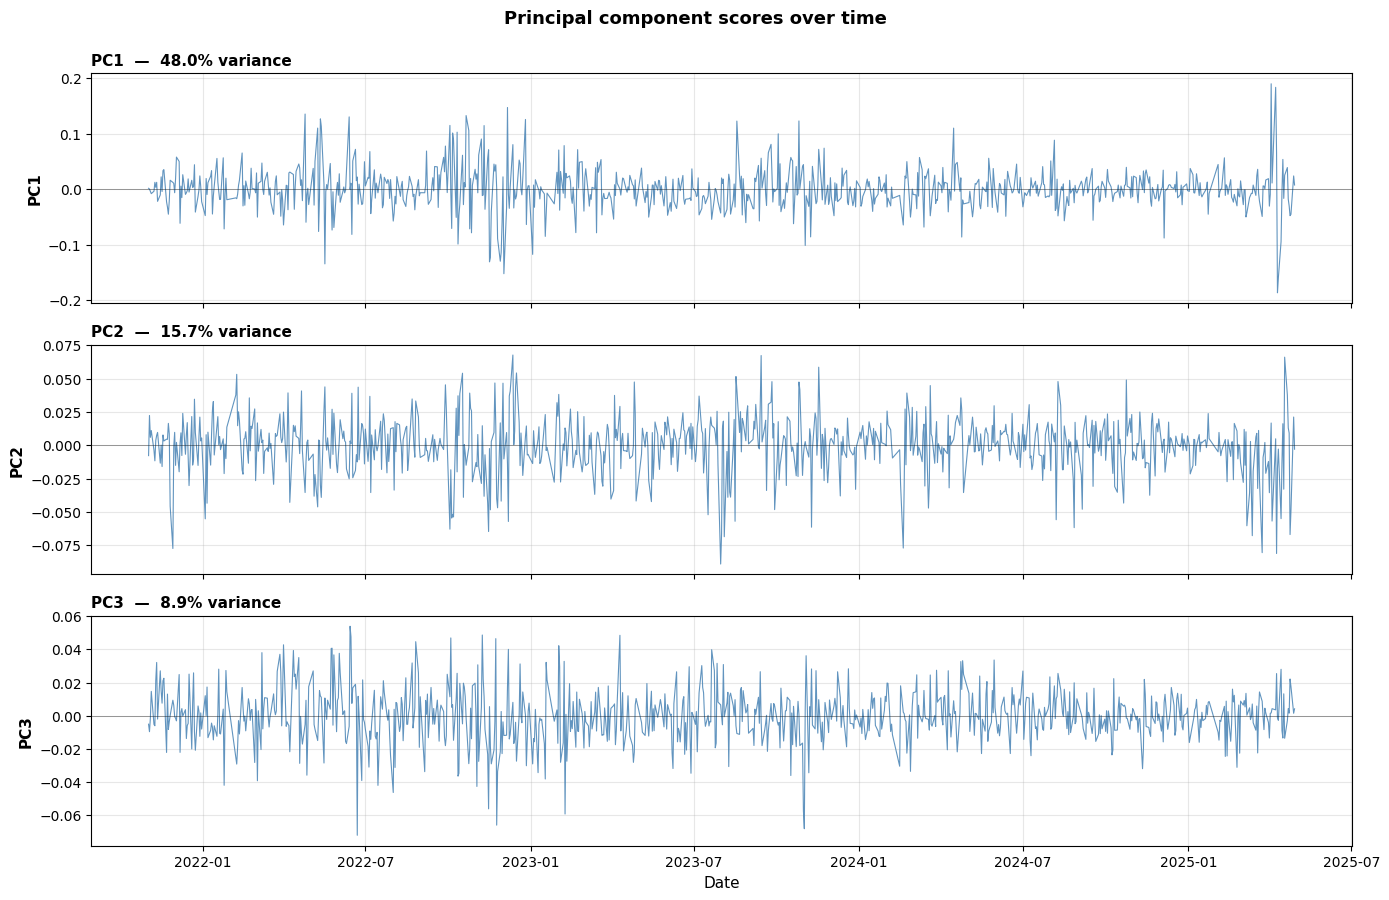

In [12]:
n_show = 3
fig, axes = plt.subplots(n_show, 1, figsize=(14, 9), sharex=True)

for i in range(n_show):
    pc_name = f'PC{i+1}'
    axes[i].plot(pc_scores.index, pc_scores[pc_name],
                 linewidth=0.8, color='steelblue', alpha=0.85)
    axes[i].axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axes[i].set_ylabel(pc_name, fontsize=11, fontweight='bold')
    axes[i].set_title(f'{pc_name}  —  {explained_variance_ratio[i]*100:.1f}% variance',
                      fontsize=11, fontweight='bold', loc='left')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Principal component scores over time',
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.decomposition import PCA

# Run sklearn PCA on the centered returns
sklearn_pca = PCA(n_components=8)
sklearn_pca.fit(X_centered)

# Extract sklearn outputs
sklearn_eigenvalues = sklearn_pca.explained_variance_      # variance per PC
sklearn_loadings    = sklearn_pca.components_.T            # transpose: rows=stocks, cols=PCs
sklearn_var_ratio   = sklearn_pca.explained_variance_ratio_

print('--- Eigenvalue comparison ---')
comparison = pd.DataFrame({
    'our_eigenvalue':     eigenvalues,
    'sklearn_eigenvalue': sklearn_eigenvalues,
    'difference':         eigenvalues - sklearn_eigenvalues,
}, index=[f'PC{i+1}' for i in range(8)])
print(comparison.round(8))

--- Eigenvalue comparison ---
     our_eigenvalue  sklearn_eigenvalue  difference
PC1        0.001376            0.001376        -0.0
PC2        0.000449            0.000449        -0.0
PC3        0.000255            0.000255        -0.0
PC4        0.000217            0.000217         0.0
PC5        0.000159            0.000159         0.0
PC6        0.000148            0.000148        -0.0
PC7        0.000145            0.000145        -0.0
PC8        0.000118            0.000118        -0.0


In [14]:
# Compare loadings (sign-aware: take absolute values to ignore sign flips)
loadings_diff = np.abs(np.abs(loadings.values) - np.abs(sklearn_loadings))
max_loading_diff = np.max(loadings_diff)

print(f'\n--- Loadings comparison ---')
print(f'Max |our_loading - sklearn_loading| (sign-corrected): {max_loading_diff:.2e}')

# Per-PC sign check
print('\nSign alignment per PC:')
for i in range(8):
    our_pc      = loadings.values[:, i]
    sklearn_pc  = sklearn_loadings[:, i]
    # Inner product close to +1 → same sign; close to -1 → flipped
    alignment   = np.dot(our_pc, sklearn_pc)
    sign        = '✓ same' if alignment > 0.99 else '⇄ flipped'
    print(f'  PC{i+1}: alignment = {alignment:+.4f}  ({sign})')


--- Loadings comparison ---
Max |our_loading - sklearn_loading| (sign-corrected): 6.82e-12

Sign alignment per PC:
  PC1: alignment = -1.0000  (⇄ flipped)
  PC2: alignment = -1.0000  (⇄ flipped)
  PC3: alignment = +1.0000  (✓ same)
  PC4: alignment = -1.0000  (⇄ flipped)
  PC5: alignment = -1.0000  (⇄ flipped)
  PC6: alignment = -1.0000  (⇄ flipped)
  PC7: alignment = +1.0000  (✓ same)
  PC8: alignment = +1.0000  (✓ same)


In [15]:
# Final check
all_eigenvalues_match = np.allclose(eigenvalues, sklearn_eigenvalues, atol=1e-10)
all_loadings_match    = np.allclose(np.abs(loadings.values),
                                     np.abs(sklearn_loadings), atol=1e-10)

print('\n=== Final verdict ===')
print(f'Eigenvalues match sklearn:                   {all_eigenvalues_match}')
print(f'Loadings match sklearn (sign-corrected):     {all_loadings_match}')

if all_eigenvalues_match and all_loadings_match:
    print('\n✓ Our from-scratch implementation matches sklearn.')


=== Final verdict ===
Eigenvalues match sklearn:                   True
Loadings match sklearn (sign-corrected):     True

✓ Our from-scratch implementation matches sklearn.


In [16]:
# Adjust for the n vs n-1 divisor difference
n = X_centered.shape[0]
sklearn_eigenvalues_adjusted = sklearn_eigenvalues * n / (n - 1)

print('--- Eigenvalue comparison (after n/(n-1) adjustment) ---')
comparison_adjusted = pd.DataFrame({
    'our_eigenvalue':              eigenvalues,
    'sklearn_eigenvalue_adjusted': sklearn_eigenvalues_adjusted,
    'difference':                  eigenvalues - sklearn_eigenvalues_adjusted,
}, index=[f'PC{i+1}' for i in range(8)])
print(comparison_adjusted.round(10))

print(f'\nMax difference after adjustment: '
      f'{np.max(np.abs(eigenvalues - sklearn_eigenvalues_adjusted)):.2e}')

--- Eigenvalue comparison (after n/(n-1) adjustment) ---
     our_eigenvalue  sklearn_eigenvalue_adjusted    difference
PC1        0.001376                     0.001378 -1.583900e-06
PC2        0.000449                     0.000450 -5.172000e-07
PC3        0.000255                     0.000255 -2.931000e-07
PC4        0.000217                     0.000217 -2.497000e-07
PC5        0.000159                     0.000159 -1.828000e-07
PC6        0.000148                     0.000148 -1.702000e-07
PC7        0.000145                     0.000145 -1.668000e-07
PC8        0.000118                     0.000118 -1.358000e-07

Max difference after adjustment: 1.58e-06


In [17]:
# Save eigenvalues and eigenvectors
np.savez('../data/pca_outputs.npz',
         eigenvalues=eigenvalues,
         eigenvectors=eigenvectors,
         tickers=np.array(tickers))

# Save PC scores as CSV (time series)
pc_scores.to_csv('../data/pc_scores.csv')

# Save loadings as CSV (for easy inspection)
loadings.to_csv('../data/pca_loadings.csv')

# Save explained variance ratios as CSV
variance_df.to_csv('../data/pca_variance.csv')

print('Saved:')
print('  ../data/pca_outputs.npz   (eigenvalues, eigenvectors, tickers)')
print('  ../data/pc_scores.csv     ', pc_scores.shape)
print('  ../data/pca_loadings.csv  ', loadings.shape)
print('  ../data/pca_variance.csv  ', variance_df.shape)

Saved:
  ../data/pca_outputs.npz   (eigenvalues, eigenvectors, tickers)
  ../data/pc_scores.csv      (870, 8)
  ../data/pca_loadings.csv   (8, 8)
  ../data/pca_variance.csv   (8, 3)


## 9. Summary

### Key findings

| Item                         | Value / observation                                                    |
|------------------------------|------------------------------------------------------------------------|
| Eigenvalues range            | $\lambda_1 = 0.00138 \to \lambda_8 = 0.00012$                          |
| PC1 (market factor)          | 48.0% of variance — broad co-movement across all 8 stocks              |
| PC2 (Vingroup factor)        | 15.7% — VIC and VHM versus the rest                                    |
| PC3 (steel vs retail)        | 8.9% — HPG opposite MWG                                                |
| Top 3 PCs cumulative         | ~73% — three interpretable factors summarize most dynamics             |
| 90% threshold                | reached at PC6                                                         |
| Verification vs sklearn      | Eigenvalues match exactly; loading magnitudes match within $10^{-12}$  |

### Linear-algebra checkpoints used in this notebook

- Verified $\Sigma$ is **symmetric** ($\max|\Sigma - \Sigma^T| \approx 0$) and **positive (semi-)definite** (all $\lambda_i > 0$).
- Eigendecomposition: $\Sigma = V \Lambda V^T$ — implemented with `np.linalg.eigh`, exploiting the symmetric structure of $\Sigma$.
- Orthogonality: $V^T V = I$ (verified to ~$10^{-15}$).
- Reconstruction: $V \Lambda V^T = \Sigma$ (verified to ~$10^{-19}$).
- Trace preservation: $\sum_i \lambda_i = \text{trace}(\Sigma)$ — confirming total variance is conserved across orthogonal change of basis.
- Projection: $Y = XV$ — change of basis from stock space to principal-component space.
- Diagonalization of $\text{Cov}(Y) = \Lambda$ — confirming the PCs are uncorrelated.

### Next step

**Notebook 04 — Moving Average Prediction:** we move from explanatory analysis to **predictive modeling**, starting with the simplest baseline — using moving averages of historical prices to forecast future prices. This will provide the first set of expected returns for the portfolio optimization in Notebook 06.